# Optimizing Early Alzheimer's Detection: Identifying the Superior Deep Learning Architecture for Disease Prediction
****
This code compares ResNet50 and VGG16 architectures for Alzheimer's disease classification using transfer learning on MRI scan data.

In [24]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, f1_score
import seaborn as sns
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

### ==================== CONFIGURATION ====================

In [25]:
BATCH_SIZE = 32 * 2  # Scaled for 2 GPUs
LEARNING_RATE = 0.001
EPOCHS = 5
FINE_TUNE_EPOCHS = 5
IMG_SIZE = 224
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "data", "AugmentedAlzheimerDataset"))

### Device Configuration

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
else:
    print("Training on single GPU/CPU")

Using device: cpu
Training on single GPU/CPU


### ==================== DATA LOADING ====================

In [27]:
def safe_loader(path):
    """Custom image loader to handle corrupted images"""
    try:
        with open(path, 'rb') as f:
            img = Image.open(f)
            return img.convert('RGB')
    except (UnidentifiedImageError, OSError):
        print(f"Skipping corrupt image: {path}")
        return Image.new('RGB', (IMG_SIZE, IMG_SIZE))

In [28]:
# Data Transforms with Augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [29]:
# Load Dataset
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform, loader=safe_loader)

In [30]:
# Split Dataset (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                          shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, 
                        shuffle=False, num_workers=0)

print(f"\nDataset Information:")
print(f"Classes: {full_dataset.classes}")
print(f"Number of classes: {len(full_dataset.classes)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")


Dataset Information:
Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Number of classes: 4
Training samples: 27187
Validation samples: 6797


In [31]:
def get_resnet50(num_classes):
    """ResNet50 model with custom classifier"""
    model = models.resnet50(pretrained=True)

    # Freeze early layers
    for param in model.parameters():
        param.requires_grad = False

    # Custom classifier
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )

    return model

def get_vgg16(num_classes):
    """VGG16 model with custom classifier"""
    model = models.vgg16(pretrained=True)

    # Freeze early layers
    for param in model.parameters():
        param.requires_grad = False

    # Custom classifier - replace last layer
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )

    return model

In [38]:
import time

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, model_name="Model"):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0

    for epoch in range(epochs):
        print(f"\n{model_name} - Epoch {epoch+1}/{epochs}")
        print("-" * 50)

        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"Train {epoch+1}/{epochs}")
        for inputs, labels in pbar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f'{correct/total:.3f}'})

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

        # Validation (this is where it looks stuck without a progress bar)
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        print("Validating...")
        t0 = time.time()
        with torch.no_grad():
            vbar = tqdm(val_loader, desc=f"Val   {epoch+1}/{epochs}")
            for inputs, labels in vbar:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                vbar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f'{val_correct/val_total:.3f}'})

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val time: {time.time()-t0:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name.lower()}.pth')
            print(f"✓ Best model saved with Val Acc: {best_val_acc:.4f}")

    return train_losses, train_accs, val_losses, val_accs

In [39]:
def evaluate_model(model, loader, class_names):
    """Comprehensive model evaluation with focus on Sensitivity (Recall)"""
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Calculate metrics
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT (Focus on Recall/Sensitivity)")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Calculate per-class recall (Sensitivity)
    recall_per_class = recall_score(y_true, y_pred, average=None)
    print("\nPer-Class Sensitivity (Recall):")
    for i, class_name in enumerate(class_names):
        print(f"  {class_name}: {recall_per_class[i]:.4f}")

    # Overall metrics
    print(f"\nOverall Metrics:")
    print(f"  Macro Avg Recall (Sensitivity): {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"  Weighted Avg Recall: {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"  Macro Avg Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"  Macro Avg F1-Score: {f1_score(y_true, y_pred, average='macro'):.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return y_true, y_pred, recall_per_class

In [40]:
def plot_training_history(history, model_name, unfreeze_point=None):
    """Plot training and validation metrics"""
    train_losses, train_accs, val_losses, val_accs = history

    plt.figure(figsize=(14, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_losses, label='Val Loss', linewidth=2)
    if unfreeze_point:
        plt.axvline(x=unfreeze_point, color='r', linestyle='--',
                   label='Fine-tuning starts', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(f'{model_name} - Loss per Epoch', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc', linewidth=2)
    plt.plot(val_accs, label='Val Acc', linewidth=2)
    if unfreeze_point:
        plt.axvline(x=unfreeze_point, color='r', linestyle='--',
                   label='Fine-tuning starts', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(f'{model_name} - Accuracy per Epoch', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [41]:
def compare_models(resnet_metrics, vgg_metrics, class_names):
    """Compare ResNet50 and VGG16 performance"""
    resnet_recall = resnet_metrics[2]
    vgg_recall = vgg_metrics[2]

    # Bar chart comparison
    x = np.arange(len(class_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width/2, resnet_recall, width, label='ResNet50', color='skyblue')
    rects2 = ax.bar(x + width/2, vgg_recall, width, label='VGG16', color='lightcoral')

    ax.set_ylabel('Sensitivity (Recall)', fontsize=12)
    ax.set_xlabel('Alzheimer Classes', fontsize=12)
    ax.set_title('Model Comparison: Sensitivity per Class', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(rect.get_x() + rect.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

    # Print summary
    print("\n" + "="*60)
    print("MODEL COMPARISON SUMMARY")
    print("="*60)
    print(f"{'Metric':<30} {'ResNet50':<15} {'VGG16':<15}")
    print("-"*60)

    resnet_avg_recall = np.mean(resnet_recall)
    vgg_avg_recall = np.mean(vgg_recall)

    print(f"{'Average Sensitivity (Recall)':<30} {resnet_avg_recall:<15.4f} {vgg_avg_recall:<15.4f}")

    winner = "ResNet50" if resnet_avg_recall > vgg_avg_recall else "VGG16"
    print(f"\n🏆 WINNER (Higher Sensitivity): {winner}")
    print("="*60)


TRAINING RESNET50

ResNet50 - Epoch 1/5
--------------------------------------------------


Train 1/5: 100%|██████████| 425/425 [40:09<00:00,  5.67s/it, loss=1.1420, acc=0.517]


Train Loss: 1.0544 | Train Acc: 0.5170
Validating...


Val   1/5: 100%|██████████| 107/107 [09:14<00:00,  5.18s/it, loss=0.8313, acc=0.613]


Val Loss: 0.8799 | Val Acc: 0.6132 | Val time: 554.7s
✓ Best model saved with Val Acc: 0.6132

ResNet50 - Epoch 2/5
--------------------------------------------------


...

Val Loss: 0.1649 | Val Acc: 0.9394 | Val time: 363.0s
✓ Best model saved with Val Acc: 0.9394

ResNet50 - Epoch 5/5
--------------------------------------------------


Train 5/5: 100%|██████████| 425/425 [1:28:57<00:00, 12.56s/it, loss=0.0056, acc=0.998]


Train Loss: 0.0112 | Train Acc: 0.9977
Validating...


Val   5/5: 100%|██████████| 107/107 [06:20<00:00,  3.56s/it, loss=0.0586, acc=0.942]


Val Loss: 0.1694 | Val Acc: 0.9425 | Val time: 380.8s
✓ Best model saved with Val Acc: 0.9425


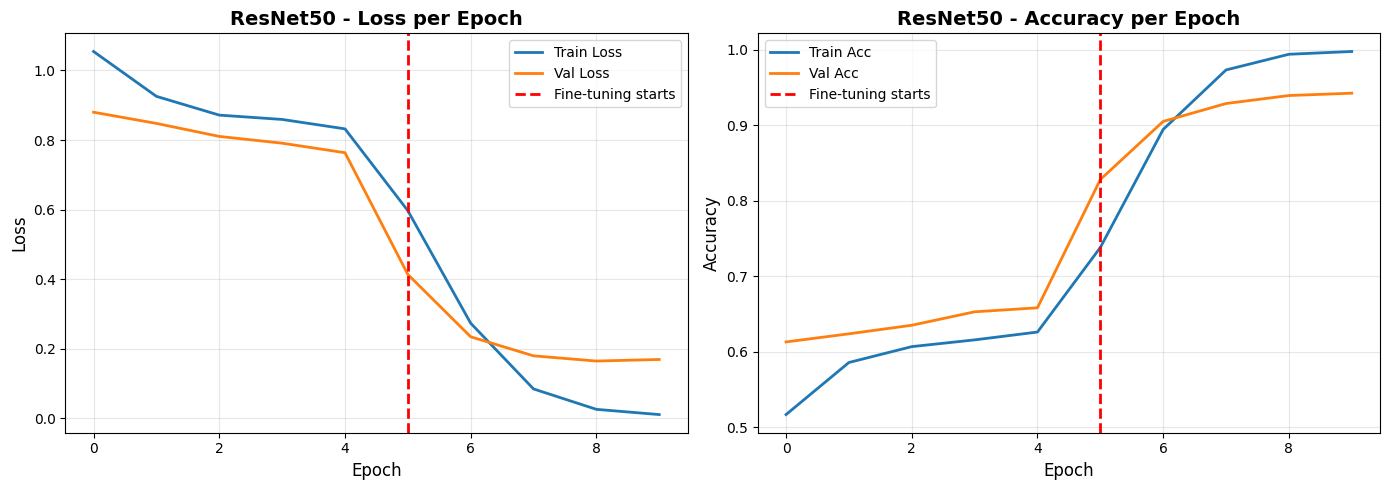

In [ ]:
print("\n" + "="*60)
print("TRAINING RESNET50")
print("="*60)

# Initialize ResNet50
resnet_model = get_resnet50(len(full_dataset.classes))
if torch.cuda.device_count() > 1:
    resnet_model = nn.DataParallel(resnet_model)
resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss()
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=LEARNIN+G_RATE)

# Train ResNet50 (Feature Extraction)
resnet_history = train_model(resnet_model, train_loader, val_loader,
                             criterion, resnet_optimizer, EPOCHS, "ResNet50")

# Fine-tune ResNet50
print("\n" + "="*60)
print("FINE-TUNING RESNET50")
print("="*60)
for param in resnet_model.parameters():
    param.requires_grad = True
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=1e-5)

resnet_history_ft = train_model(resnet_model, train_loader, val_loader,
                                criterion, resnet_optimizer, FINE_TUNE_EPOCHS, "ResNet50")

# Combine histories
resnet_full_history = (
    resnet_history[0] + resnet_history_ft[0],
    resnet_history[1] + resnet_history_ft[1],
    resnet_history[2] + resnet_history_ft[2],
    resnet_history[3] + resnet_history_ft[3]
)

plot_training_history(resnet_full_history, "ResNet50", unfreeze_point=EPOCHS)


TRAINING VGG16

VGG16 - Epoch 1/5
--------------------------------------------------


Train 1/5: 100%|██████████| 425/425 [1:13:41<00:00, 10.40s/it, loss=1.1362, acc=0.465]


Train Loss: 1.1432 | Train Acc: 0.4651
Validating...


Val   1/5: 100%|██████████| 107/107 [18:17<00:00, 10.25s/it, loss=1.0071, acc=0.584]


Val Loss: 0.9932 | Val Acc: 0.5841 | Val time: 1097.1s
✓ Best model saved with Val Acc: 0.5841

VGG16 - Epoch 2/5
--------------------------------------------------


...

Val Loss: 0.1220 | Val Acc: 0.9584 | Val time: 1064.9s

VGG16 - Epoch 5/5
--------------------------------------------------


Train 5/5: 100%|██████████| 425/425 [8:45:18<00:00, 74.16s/it, loss=0.0127, acc=0.987]      


Train Loss: 0.0392 | Train Acc: 0.9874
Validating...


Val   5/5: 100%|██████████| 107/107 [16:34<00:00,  9.30s/it, loss=0.0128, acc=0.978]


Val Loss: 0.0653 | Val Acc: 0.9776 | Val time: 994.6s
✓ Best model saved with Val Acc: 0.9776


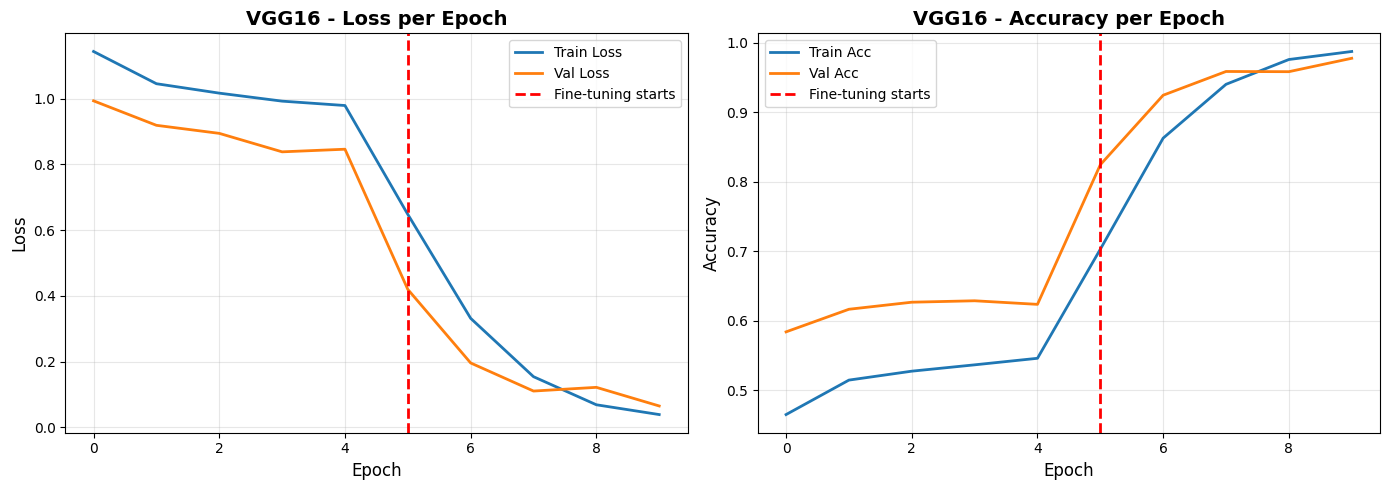

In [44]:
print("\n" + "="*60)
print("TRAINING VGG16")
print("="*60)

# Initialize VGG16
vgg_model = get_vgg16(len(full_dataset.classes))
if torch.cuda.device_count() > 1:
    vgg_model = nn.DataParallel(vgg_model)
vgg_model = vgg_model.to(device)

vgg_optimizer = optim.Adam(vgg_model.parameters(), lr=LEARNING_RATE)

# Train VGG16 (Feature Extraction)
vgg_history = train_model(vgg_model, train_loader, val_loader,
                         criterion, vgg_optimizer, EPOCHS, "VGG16")

# Fine-tune VGG16
print("\n" + "="*60)
print("FINE-TUNING VGG16")
print("="*60)
for param in vgg_model.parameters():
    param.requires_grad = True
vgg_optimizer = optim.Adam(vgg_model.parameters(), lr=1e-5)

vgg_history_ft = train_model(vgg_model, train_loader, val_loader,
                            criterion, vgg_optimizer, FINE_TUNE_EPOCHS, "VGG16")

# Combine histories
vgg_full_history = (
    vgg_history[0] + vgg_history_ft[0],
    vgg_history[1] + vgg_history_ft[1],
    vgg_history[2] + vgg_history_ft[2],
    vgg_history[3] + vgg_history_ft[3]
)

plot_training_history(vgg_full_history, "VGG16", unfreeze_point=EPOCHS)

### ==================== MODEL EVALUATION ====================


EVALUATING RESNET50

CLASSIFICATION REPORT (Focus on Recall/Sensitivity)
                  precision    recall  f1-score   support

    MildDemented     0.9222    0.9761    0.9484      1761
ModerateDemented     0.9977    1.0000    0.9989      1326
     NonDemented     0.9379    0.9246    0.9312      1896
VeryMildDemented     0.9268    0.8864    0.9062      1814

        accuracy                         0.9425      6797
       macro avg     0.9462    0.9468    0.9462      6797
    weighted avg     0.9426    0.9425    0.9422      6797


Per-Class Sensitivity (Recall):
  MildDemented: 0.9761
  ModerateDemented: 1.0000
  NonDemented: 0.9246
  VeryMildDemented: 0.8864

Overall Metrics:
  Macro Avg Recall (Sensitivity): 0.9468
  Weighted Avg Recall: 0.9425
  Macro Avg Precision: 0.9462
  Macro Avg F1-Score: 0.9462


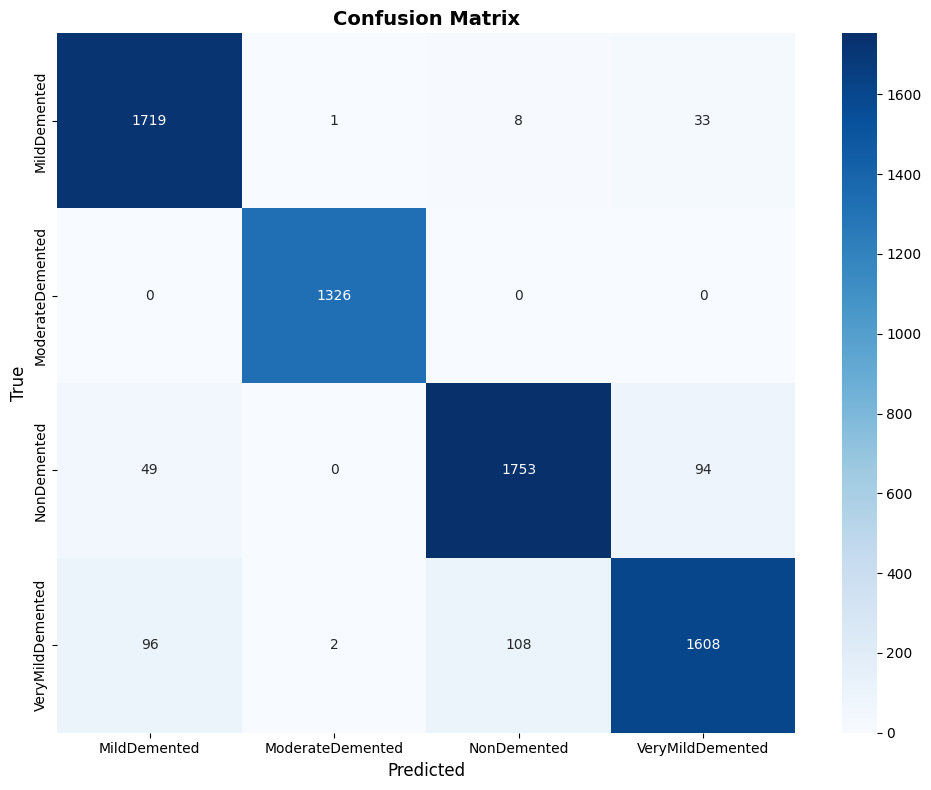


EVALUATING VGG16

CLASSIFICATION REPORT (Focus on Recall/Sensitivity)
                  precision    recall  f1-score   support

    MildDemented     0.9760    0.9949    0.9854      1761
ModerateDemented     1.0000    1.0000    1.0000      1326
     NonDemented     0.9613    0.9815    0.9713      1896
VeryMildDemented     0.9805    0.9405    0.9600      1814

        accuracy                         0.9776      6797
       macro avg     0.9794    0.9792    0.9792      6797
    weighted avg     0.9778    0.9776    0.9775      6797


Per-Class Sensitivity (Recall):
  MildDemented: 0.9949
  ModerateDemented: 1.0000
  NonDemented: 0.9815
  VeryMildDemented: 0.9405

Overall Metrics:
  Macro Avg Recall (Sensitivity): 0.9792
  Weighted Avg Recall: 0.9776
  Macro Avg Precision: 0.9794
  Macro Avg F1-Score: 0.9792


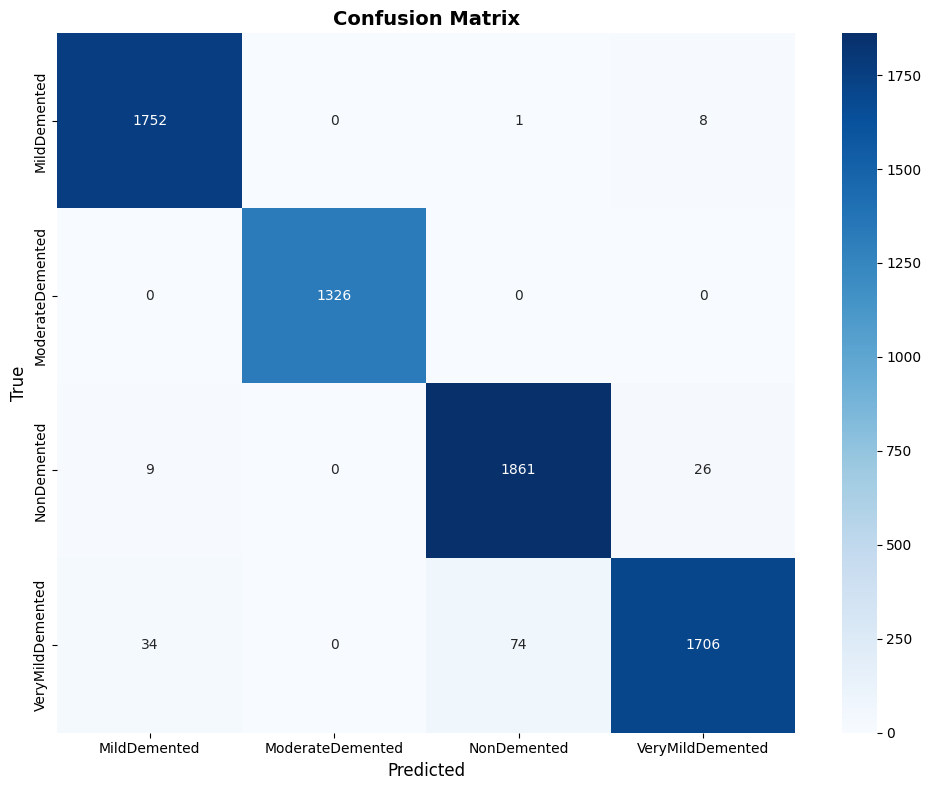

In [45]:
print("\n" + "="*60)
print("EVALUATING RESNET50")
print("="*60)
resnet_metrics = evaluate_model(resnet_model, val_loader, full_dataset.classes)

print("\n" + "="*60)
print("EVALUATING VGG16")
print("="*60)
vgg_metrics = evaluate_model(vgg_model, val_loader, full_dataset.classes)

### ==================== FINAL COMPARISON ====================

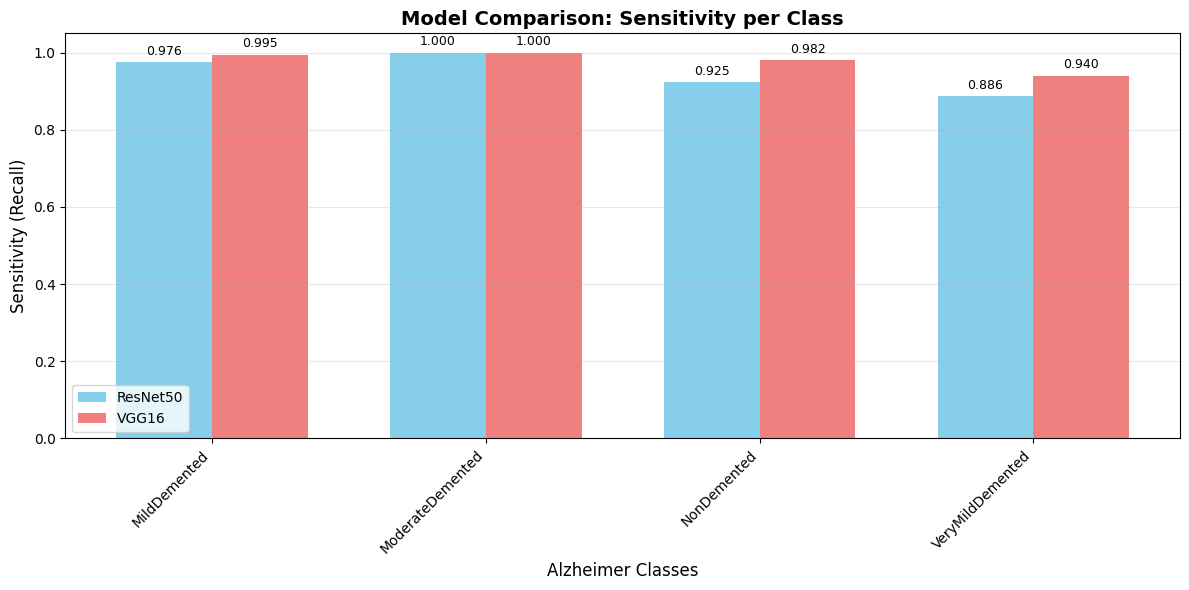


MODEL COMPARISON SUMMARY
Metric                         ResNet50        VGG16          
------------------------------------------------------------
Average Sensitivity (Recall)   0.9468          0.9792         

🏆 WINNER (Higher Sensitivity): VGG16


In [46]:
compare_models(resnet_metrics, vgg_metrics, full_dataset.classes)

### ==================== SAVE MODELS ====================

In [47]:
torch.save(resnet_model.state_dict(), 'alzheimer_resnet50_final.pth')
torch.save(vgg_model.state_dict(), 'alzheimer_vgg16_final.pth')
print("\n✓ Models saved successfully!")
print("  - alzheimer_resnet50_final.pth")
print("  - alzheimer_vgg16_final.pth")


✓ Models saved successfully!
  - alzheimer_resnet50_final.pth
  - alzheimer_vgg16_final.pth


### ==================== PREDICTION FUNCTION ====================

In [48]:
def predict_image(image_path, model, model_name):
    """Predict single image"""
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        img_tensor = img_tensor.to(device)
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    class_name = full_dataset.classes[predicted.item()]
    confidence_score = confidence.item()

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"{model_name}\nPrediction: {class_name} (Confidence: {confidence_score:.2%})",
             fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return class_name, confidence_score